1. Write code that allows you to construct a dataset which combines the images and
provides the appropriate labels. The input images should be of shape $56 \times 28$. Generate
appropriate training, validation, and test datasets. Justify your choices in the generation
of these datasets, i.e. ensure that the appropriate statistical properties are guaranteed.

In [2]:
import tensorflow as tf
import sklearn 
import optuna
import matplotlib.pyplot as plt
import pandas as pd 



###  Create $56 \times 28$ images dataset

In [286]:
from tensorflow.keras.datasets import mnist # importing 28x28 dataset

(x_train, y_train), (x_test, y_test) = mnist.load_data() # loading the data splitting into x_train, y_train and x_test, y_test

#  checing if data is loaded correctly
print('Train set shape images:',x_train.shape) 
print('Test set shape images:',x_test.shape)
print('Train set shape label:',y_train.shape) 
print('Test set shape label:',y_test.shape)

Train set shape images: (60000, 28, 28)
Test set shape images: (10000, 28, 28)
Train set shape label: (60000,)
Test set shape label: (10000,)


In [4]:
import numpy as np

np.random.seed(1) # fixed dataset
# Initialising parameters
# try 
#total_size = 30000 # total dataset size
total_size = 0.8*10**5 # total dataset size 
N_train = int(total_size*0.8) # training dataset size
N_test = int(total_size*0.2) # test dataset size

lenght_train = len(x_train)
lenght_test = len(x_test)

# Generating pairs of images for training and test dataset
x_train_pair = np.random.choice(np.arange(lenght_train), size = (N_train, 2))
x_test_pair = np.random.choice(np.arange(lenght_test), size = (N_test, 2))

# Summing the values of each images from training and test datasets
y_train_new = y_train[x_train_pair[:,0]] + y_train[x_train_pair[:,1]]
y_test_new = y_test[x_test_pair[:,0]] + y_test[x_test_pair[:,1]]

# Generating 56x28 images
x_train_new = np.append(x_train[x_train_pair[:,0]], x_train[x_train_pair[:,1]], axis=1)
x_test_new = np.append(x_test[x_test_pair[:,0]], x_test[x_test_pair[:,1]], axis=1)


#### Checking if the shape of our new datasets is correct!

In [5]:
# Chacking if the shape the paired dataset is correct

assert x_train_new.shape==(N_train,56,28)
assert x_test_new.shape==(N_test,56,28)
assert y_train_new.shape==(N_train,)
assert y_test_new.shape==(N_test,)

#### Visualising Datasets

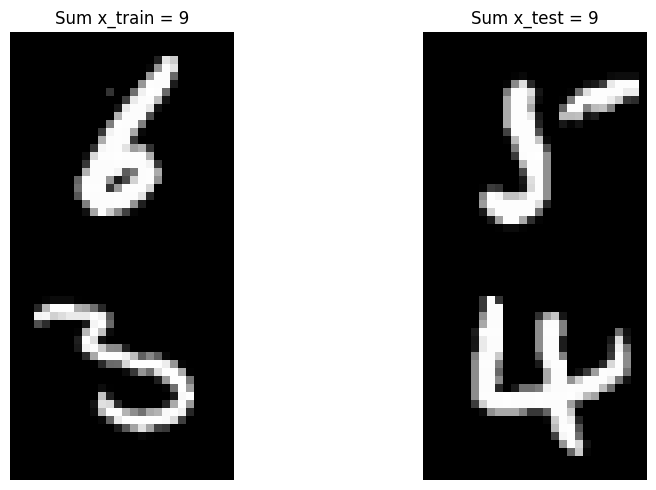

In [6]:
# chose at random from both datasets train/test 
pos_train = np.random.randint(N_train)
pos_test = np.random.randint(N_test)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Display the first image in the first subplot
axes[0].imshow(x_train_new[pos_train], cmap='gray')
axes[0].set_title(f'Sum x_train = {y_train_new[pos_train]}')
axes[0].axis('off')  # Hide the axes

# Display the second image in the second subplot
axes[1].imshow(x_test_new[pos_test], cmap='gray')
axes[1].set_title(f'Sum x_test = {y_test_new[pos_test]}')
axes[1].axis('off')  # Hide the axes

# Show the figure
plt.tight_layout()
plt.show()


2. Using these datasets, develop a neural network pipeline using fully connected neural networks which allows you to address this inference/classification process. The output of your neural network can correspond to a single number, e.g. $7+3=10$. You should perform some hyper-parameter tuning to establish a good architecture (a choice of five hyper-parameters is what we look for and you should restrict the number of experiments that you can run them on a personal laptop using no more than a few hours). Your report should include a short overview of the results you have obtained in this hyper-parameter search. You should provide the weights of your best performing neural network and the neural networks utilised in plots (i.e. the plots should be reproducible).

### Developing A Fully Connected Neural Network 

Imporint required packahes

In [288]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  1


In [297]:
import optuna
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist #to import our dataset
from tensorflow.keras.models import Sequential, Model # imports our type of network
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input, BatchNormalization # imports our layers we want to use

from tensorflow.python.keras.losses import categorical_crossentropy #loss function
from tensorflow.keras.optimizers import Adam, SGD #optimisers
from tensorflow.keras.utils import to_categorical #some function for data preparation

from tensorflow.keras.callbacks import ModelCheckpoint #checkpoints used to keep track of best model

Preparing dataset for neural network

In [298]:
batch_size = 2**7 
num_classes = 19
epochs = 20

# input image dimensions
img_rows, img_cols = 56, 28
# normalising images
x_train_ = x_train_new.astype('float32')
x_test_ = x_test_new.astype('float32')
x_train_/=255 # max value for each pixel
x_test_/=255
print('x_train shape:', x_train_new.shape)
print(x_train_new.shape[0], 'train samples')
print(x_test_new.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train_flatten = to_categorical(y_train_new, num_classes)
y_test_flatten = to_categorical(y_test_new, num_classes)

x_train shape: (60000, 56, 28)
60000 train samples
10000 test samples


#### Constucting neural network with no tuning of hyper-parameters

In [11]:
model1 = Sequential()
model1.add(Flatten())
model1.add(Dense(batch_size, activation='relu'))
model1.add(Dense(num_classes, activation='softmax'))

model1.compile(loss=categorical_crossentropy,
              optimizer=Adam(), metrics=['accuracy'])

I0000 00:00:1734197803.346883  183137 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [10]:
history_1=model1.fit(x_train_, y_train_flatten,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test_, y_test_flatten))

Epoch 1/20


2024-12-04 23:13:33.938129: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 401408000 exceeds 10% of free system memory.
2024-12-04 23:13:34.200929: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 401408000 exceeds 10% of free system memory.
I0000 00:00:1733354015.005168  361080 service.cc:148] XLA service 0x7f5808014710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1733354015.005452  361080 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Laptop GPU, Compute Capability 8.6
2024-12-04 23:13:35.064259: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1733354015.218618  361080 cuda_dnn.cc:529] Loaded cuDNN version 90300
2024-12-04 23:13:37.151845: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Re

 50/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1150 - loss: 2.7685

I0000 00:00:1733354017.910475  361080 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2719 - loss: 2.2515 - val_accuracy: 0.6079 - val_loss: 1.2744
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6456 - loss: 1.1618 - val_accuracy: 0.6982 - val_loss: 0.9813
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7340 - loss: 0.8848 - val_accuracy: 0.7309 - val_loss: 0.8761
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7663 - loss: 0.7732 - val_accuracy: 0.7445 - val_loss: 0.8366
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7965 - loss: 0.6819 - val_accuracy: 0.7557 - val_loss: 0.8094
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8140 - loss: 0.6200 - val_accuracy: 0.7585 - val_loss: 0.7930
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8289 - loss: 0.5726 - val_accuracy: 0.7607 - val_loss: 0.7851
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8417 - loss: 0.5300 - val_accuracy: 0.7623 - val_

In [11]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (128, 1568)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (128, 128)             │       200,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (128, 19)              │         2,451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609,851 (2.33 MB)

 Trainable params: 203,283 (794.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 406,568 (1.55 MB)

#### Some plots before Hyper-Parameter Tuning

In particular number of epochs vs validation loss

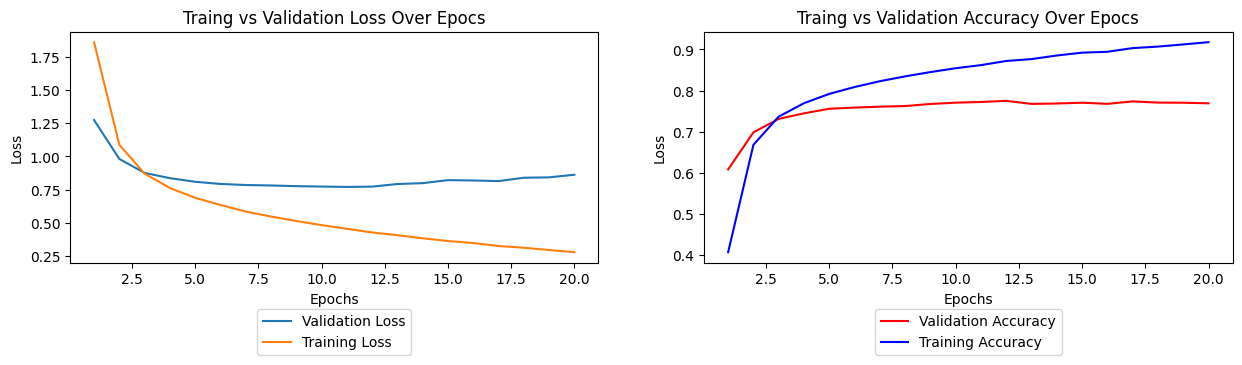

In [63]:
# Collecting information from history_1
# Traing, 
t_accuracy_array = history_1.history['accuracy'] # Accuracy
tra_loss_array = history_1.history['loss'] # Loss

# Validation,
val_accuracy_array = history_1.history['val_accuracy'] # Accuracy
val_loss_array = history_1.history['val_loss'] # Loss

epochs_space = np.arange(1, len(val_loss_array)+1) # Number of epochs utilised

#  Setting up a subplot
fig, ax = plt.subplots(1,2,figsize=(15,3))

# Plotting the results
ax[0].plot(epochs_space, val_loss_array, label = 'Validation Loss')
ax[0].plot(epochs_space, tra_loss_array, label  = 'Training Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Traing vs Validation Loss Over Epocs')
ax[0].legend(loc = 'center', bbox_to_anchor=(0.5, -0.3))

ax[1].plot(epochs_space, val_accuracy_array, label = 'Validation Accuracy', color = 'red')
ax[1].plot(epochs_space, t_accuracy_array, label  = 'Training Accuracy', color = 'blue')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].set_title('Traing vs Validation Accuracy Over Epocs')
ax[1].legend(loc = 'center', bbox_to_anchor=(0.5, -0.3))
plt.savefig('model1.png', bbox_inches='tight')


From the above output, one can observe that the loss value decreases up to a specific epoch. But if iterations are continued, the loss value will start increasing again, this suggest that the neural network start to overfit. To avoid overfitting one can:
- Use regularisation (e.g. linear and ridge regularisation, often referred as L1 and L2)
- Dropout (disconect random neurons)
- Batch Normalisation (already applied, i.e. divide $x_{train}$ and $x_{test}$ by $255$, as the pixel value in MNIST ranges between $0$ and $255$, this represent the grayscale intensities)

#### Hyper Parameter Tuning

optuna is a python package that allows hyper-parameter tuning, for more information on optuna and examples please see [link](https://pypi.org/project/optuna/). 

In [13]:
import optuna

# Optuna objective function
def objective(trial):

    """
    Objective function to optimize hyperparameters using optuna.

    Input:
        trial: A trial object used to suggest hyperparameter values.

    Returns:
        Accuracy of the model on the validation dataset.
    """
#loss
    # Suggest hyperparameters to be optimised
    num_layers = trial.suggest_int('num_layers', 1, 3) # Number of fully conected layers
    activation = trial.suggest_categorical('activation', ['relu', 'sigmoid', 'tanh', 'softmax']) # Activation functions
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.8) # Dropping neurons at random (reduce overfitting)
    units = trial.suggest_int('units', 32, 256) # Number of neurons in each dense layer
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True) # Try for different values of learning rate 
    
    # Build the model
    model = Sequential() # Sequential model adds one layer at the time "linear stack of layers"
    model.add(Flatten(input_shape=(56, 28))) # Flattening 2D image into 1D arrat (vector size 56*28 = 1568)
    
    # Adding fully connected and dropout layers dynamically based on num_layers
    for _ in range(num_layers): 
        model.add(Dense(units=units, activation=activation)) # Fully connected layer
        model.add(Dropout(rate=dropout_rate)) # Regularisation through dropout
    
    # Adding output layer
    model.add(Dense(19, activation='softmax')) # Output layer with 19 classes
    
    # Compile the model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), # Adam optimiser with dynamic learing rate
                  loss='categorical_crossentropy', # Loss fucntion for multi-class classification (i.e. categorical crossentropy)
                  metrics=['accuracy']) # Metric evaluation during training
    
    # Train the model
    history = model.fit(x_train_, y_train_flatten, # Traing data input (x_train_), and target label (y_train_flatten)
                        validation_split=0.2, # Use 20% of training data for validation
                        epochs=epochs,  # Number of epochs
                        batch_size=128, # Batch size
                        verbose=0 # Suppressing training output for cleaner optuna logs
                        )
    
    # Evaluate the model on the test dataset
    score = model.evaluate(x_test_, y_test_flatten, verbose=0) # Evaluate silently
    accuracy = score[1] # Extract the accuracy from the evolution result
    return accuracy # Return accuracy to optuna for optimisation

# Create an Optuna study and optimize the objective function
study2 = optuna.create_study(direction='maximize') # Optimise for maximum accuracy
study2.optimize(objective, n_trials=20)  # Run 20 times with different hyper-parameter configuration

# Print the best trial
print('Best trial:')
print(f' Value: {study2.best_trial.value}') # Best accuracy achieved
print(' Params: ')
for key, value in study2.best_trial.params.items(): # List the best hyper-parameter configuration
    print(f'    {key}: {value}')

[I 2024-12-04 23:14:30,566] A new study created in memory with name: no-name-28183621-d6d0-4a21-bc9f-718b5e84f962
/root/Document/M1_Cw/mem97/ml_venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2024-12-04 23:14:34.248532: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1463', 16 bytes spill stores, 16 bytes spill loads

[I 2024-12-04 23:15:10,605] Trial 0 finished with value: 0.1028124988079071 and parameters: {'num_layers': 3, 'activation': 'softmax', 'dropout_rate': 0.04634805131818594, 'units': 109, 'learning_rate': 3.293557822127448e-05}. Best is trial 0 with value: 0.1028124988079071.
2024-12-04 23:15:13.197933: I external/local_xla/xla/stre

Best trial:
 Value: 0.9003124833106995
 Params: 
    num_layers: 2
    activation: relu
    dropout_rate: 0.13288286791395848
    units: 236
    learning_rate: 0.0036462592000901686


#### Neural Network after Hyper-Parameter Tuning

In [14]:
# Collecting best performing hyperparameters

short2 = study2.best_trial.params # saving wrtiting

# Best performing hyper-parameters 
num_layers2 = short2['num_layers']
activation2 = f'{short2['activation']}'
dropout_rate2 = short2['dropout_rate']
units2 = short2['units']
learning_rate2 = short2['learning_rate']

In [ ]:
data2 = ({
    'Number of Layers':[num_layers2],
    'Activation Function':[activation2],
    'Drop out Rate':[dropout_rate2],
    'Number of Units':[units2],
    'Learning Rate':[learning_rate2],
    'Regualrisation Type':['/'],
    'L1 Strenght':['/'],
    'L2 Strenght':['/']
})

model_hp = pd.DataFrame(data2)
# saving 
#model_hp.to_csv('model2_hp.csv', index=False)

In [15]:

# Build the model
epochs=50
model2 = Sequential() # Sequential model adds one layer at the time "linear stack of layers"
model2.add(Flatten(input_shape=(56, 28))) # Flattening 2D image into 1D arrat (vector size 56*28 = 1568)
    
# Adding fully connected and dropout layers dynamically based on num_layers
for _ in range(num_layers2): 
    model2.add(Dense(units=units2, activation=activation2)) # Fully connected layer
    model2.add(Dropout(rate=dropout_rate2)) # Regularisation through dropout
    
# Adding output layer
model2.add(Dense(19, activation='softmax')) # Output layer with 19 classes
    
# Compile the model
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate2), # Adam optimiser with dynamic learing rate
            loss='categorical_crossentropy', # Loss fucntion for multi-class classification (i.e. categorical crossentropy)
            metrics=['accuracy']) # Metric evaluation during training
    
# Train the model
history_2=model2.fit(x_train_, y_train_flatten,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test_, y_test_flatten))

Epoch 1/50


2024-12-04 23:29:05.624906: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 401408000 exceeds 10% of free system memory.
2024-12-04 23:29:05.964141: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 401408000 exceeds 10% of free system memory.


500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3870 - loss: 1.8602 - val_accuracy: 0.7899 - val_loss: 0.6856
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7784 - loss: 0.7323 - val_accuracy: 0.8401 - val_loss: 0.5354
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8319 - loss: 0.5665 - val_accuracy: 0.8651 - val_loss: 0.4808
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8588 - loss: 0.4791 - val_accuracy: 0.8717 - val_loss: 0.4559
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8716 - loss: 0.4400 - val_accuracy: 0.8797 - val_loss: 0.4261
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8873 - loss: 0.3833 - val_accuracy: 0.8864 - val_loss: 0.4205
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8925 - loss: 0.3692 - val_accuracy: 0.8878 - val_loss: 0.4189
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9013 - loss: 0.3386 - val_accuracy: 0.8951 - val_

In [16]:
model2.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_21 (Flatten)            │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 236)            │       370,284 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 236)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 236)            │        55,932 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 236)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 19)             │         4,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,159 (4.93 MB)

 Trainable params: 430,719 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 861,440 (3.29 MB)

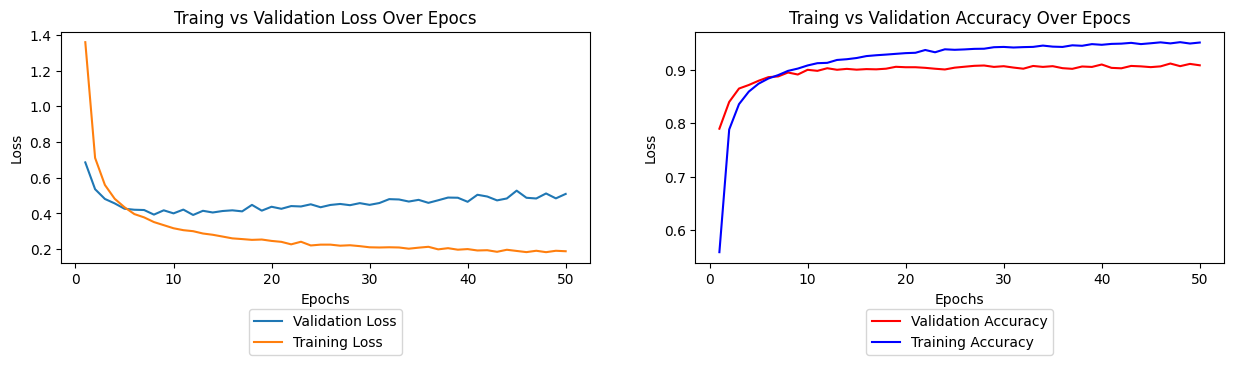

In [ ]:
# Collecting information from history_2
# Traing, 
t_accuracy_array = history_2.history['accuracy'] # Accuracy
tra_loss_array = history_2.history['loss'] # Loss

# Validation,
val_accuracy_array = history_2.history['val_accuracy'] # Accuracy
val_loss_array = history_2.history['val_loss'] # Loss

epochs_space = np.arange(1, len(val_loss_array)+1) # Number of epochs utilised

#  Setting up a subplot
fig, ax = plt.subplots(1,2,figsize=(15,3))

# Plotting the results
ax[0].plot(epochs_space, val_loss_array, label = 'Validation Loss')
ax[0].plot(epochs_space, tra_loss_array, label  = 'Training Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Traing vs Validation Loss Over Epocs')
ax[0].legend(loc = 'center', bbox_to_anchor=(0.5, -0.3))

ax[1].plot(epochs_space, val_accuracy_array, label = 'Validation Accuracy', color = 'red')
ax[1].plot(epochs_space, t_accuracy_array, label  = 'Training Accuracy', color = 'blue')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].set_title('Traing vs Validation Accuracy Over Epocs')
ax[1].legend(loc = 'center', bbox_to_anchor=(0.5, -0.3))
# saving the plot
#plt.savefig('model2.png', bbox_inches='tight')

Same as befor but using `ModelCheckpoint`

In [18]:

# Define a ModelCheckpoint callback
checkpoint = ModelCheckpoint('best_model.keras', 
                             monitor='val_accuracy',  # You can monitor 'val_loss' or any other metric
                             save_best_only=True, 
                             mode='max',  # Use 'max' if monitoring accuracy; 'min' if monitoring loss
                             verbose=1)

# Build the model
epochs=50
model2_with_checkpoint = Sequential() # Sequential model adds one layer at the time "linear stack of layers"
model2_with_checkpoint.add(Flatten(input_shape=(56, 28))) # Flattening 2D image into 1D arrat (vector size 56*28 = 1568)
    
# Adding fully connected and dropout layers dynamically based on num_layers
for _ in range(num_layers2): 
    model2_with_checkpoint.add(Dense(units=units2, activation=activation2)) # Fully connected layer
    model2_with_checkpoint.add(Dropout(rate=dropout_rate2)) # Regularisation through dropout
    
# Adding output layer
model2_with_checkpoint.add(Dense(19, activation='softmax')) # Output layer with 19 classes
    
# Compile the model
model2_with_checkpoint.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate2), # Adam optimiser with dynamic learing rate
            loss='categorical_crossentropy', # Loss fucntion for multi-class classification (i.e. categorical crossentropy)
            metrics=['accuracy']) # Metric evaluation during training
    
# Train the model
history_2_with_checkpoint=model2_with_checkpoint.fit(x_train_, y_train_flatten,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test_, y_test_flatten))

Epoch 1/50


2024-12-04 23:31:15.132748: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 401408000 exceeds 10% of free system memory.


500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3715 - loss: 1.9000 - val_accuracy: 0.7866 - val_loss: 0.7239
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7627 - loss: 0.7757 - val_accuracy: 0.8339 - val_loss: 0.5630
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8239 - loss: 0.5921 - val_accuracy: 0.8591 - val_loss: 0.4864
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8536 - loss: 0.4907 - val_accuracy: 0.8706 - val_loss: 0.4558
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8706 - loss: 0.4417 - val_accuracy: 0.8749 - val_loss: 0.4484
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8780 - loss: 0.4164 - val_accuracy: 0.8859 - val_loss: 0.4034
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8883 - loss: 0.3751 - val_accuracy: 0.8879 - val_loss: 0.4204
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8935 - loss: 0.3606 - val_accuracy: 0.8888 - val_

We can observe that after tuning our hyper-parameters, validation accuracy imporves, however the model is still subject to overfitting. To tackle this probem one could implement more hyper-parameters, namely L1, L2 and a combination of the two.

In [19]:
from tensorflow.keras.regularizers import l1, l2, l1_l2
import optuna
epochs = 20
# Optuna objective function
def objective(trial):
    """
    Objective function to optimize hyperparameters using Optuna.

    Input:
        trial: A trial object used to suggest hyperparameter values.

    Returns:
        Accuracy of the model on the validation dataset.
    """
    # Suggest hyperparameters to be optimized
    num_layers = trial.suggest_int('num_layers', 1, 3)  # Number of fully connected layers
    activation = trial.suggest_categorical('activation', ['relu', 'sigmoid', 'tanh'])  # Activation functions
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5)  # Dropping neurons at random (reduce overfitting)
    units = trial.suggest_int('units', 32, 256)  # Number of neurons in each dense layer
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)  # Learning rate
    reg_type = trial.suggest_categorical('reg_type', ['l1', 'l2', 'l1_l2'])  # Type of regularization
    reg_strength_l1 = trial.suggest_float('reg_strength_l1', 1e-5, 1e-2, log=True)
    reg_strength_l2 = trial.suggest_float('reg_strength_l2', 1e-5, 1e-2, log=True)
    
    # Choose the appropriate regularizer
    if reg_type == 'l1':
        regularizer = l1(reg_strength_l1)
    elif reg_type == 'l2':
        regularizer = l2(reg_strength_l2)
    elif reg_type == 'l1_l2':
        regularizer = l1_l2(l1=reg_strength_l1, l2=reg_strength_l2)

    # Build the model
    model = Sequential()
    model.add(Flatten(input_shape=(56, 28)))

    # Adding fully connected and dropout layers dynamically based on num_layers
    for _ in range(num_layers):
        model.add(Dense(units=units, activation=activation, kernel_regularizer=regularizer))
        model.add(Dropout(rate=dropout_rate))

    # Adding output layer
    model.add(Dense(19, activation='softmax'))  # Output layer with 19 classes

    # Compile the model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the model
    history = model.fit(x_train_, y_train_flatten,
                        validation_split=0.2,
                        epochs=epochs,
                        batch_size=batch_size,
                        verbose=0)

    # Evaluate the model on the test dataset
    score = model.evaluate(x_test_, y_test_flatten, verbose=0)
    accuracy = score[1]  # Extract the accuracy from the evaluation result
    return accuracy  # Return accuracy to Optuna for optimization

# Create an Optuna study and optimize the objective function
study3 = optuna.create_study(direction='maximize')  # Optimize for maximum accuracy
study3.optimize(objective, n_trials=20)  # Run 20 trials with different hyperparameter configurations

# Print the best trial
print('Best trial:')
print(f' Value: {study3.best_trial.value}')  # Best accuracy achieved
print(' Params: ')
for key, value in study3.best_trial.params.items():  # List the best hyperparameter configuration
    print(f'    {key}: {value}')


[I 2024-12-04 23:33:17,235] A new study created in memory with name: no-name-93ac728e-d669-4b49-ba85-48d35f3bb59a


2024-12-04 23:33:19.300226: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1087', 4 bytes spill stores, 4 bytes spill loads

2024-12-04 23:33:23.466701: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_98', 48 bytes spill stores, 48 bytes spill loads

2024-12-04 23:33:23.641162: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_103', 8 bytes spill stores, 8 bytes spill loads

2024-12-04 23:33:24.113409: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_103', 80 bytes spill stores, 80 bytes spill loads

2024-12-04 23:33:24.307275: I external/local_xla/xla/stream_executor

Best trial:
 Value: 0.8973749876022339
 Params: 
    num_layers: 2
    activation: sigmoid
    dropout_rate: 0.0590731237212877
    units: 253
    learning_rate: 0.005196484442711773
    reg_type: l1
    reg_strength_l1: 2.06694264447087e-05
    reg_strength_l2: 0.0005409544812395567


In [47]:
# Collecting best performing hyperparameters

short3 = study3.best_trial.params # saving wrtiting

# Best performing hyper-parameters 
num_layers3 = short3['num_layers']
activation3 = short3['activation']
dropout_rate3 = short3['dropout_rate']
units3 = short3['units']
learning_rate3 = short3['learning_rate']
reg_type3 = short3['reg_type']
reg_strength_l1 = short3['reg_strength_l1']
reg_strength_l2 = short3['reg_strength_l2']

In [ ]:


data3 = ({
    'Number of Layers':[num_layers3],
    'Activation Function':[activation3],
    'Drop out Rate':[dropout_rate3],
    'Number of Units':[units3],
    'Learning Rate':[learning_rate3],
    'Regualrisation Type':[reg_type3],
    'L1 Strenght':[reg_strength_l1],
    'L2 Strenght':[reg_strength_l2]
})

best_model_hp = pd.DataFrame(data3)
# saving
#best_model_hp.to_csv('best_model_hp.csv', index=False)


In [50]:
epochs = 50
# chosing the appropriate reguliser based on the result obtained from hyper-parameter tuning
if reg_type3 == 'l1':
    regularizer = l1(reg_strength_l1)
elif reg_type3 == 'l2':
    regularizer = l2(reg_strength_l2)
elif reg_type3 == 'l1_l2':
    regularizer = l1_l2(l1=reg_strength_l1, l2=reg_strength_l2)

# Build the model
model3 = Sequential() # Sequential model adds one layer at the time "linear stack of layers"
model3.add(Flatten(input_shape=(56, 28))) # Flattening 2D image into 1D arrat (vector size 56*28 = 1568)
    
# Adding fully connected and dropout layers dynamically based on num_layers
for _ in range(num_layers3): 
    model3.add(Dense(units=units3, activation=activation3, kernel_regularizer=regularizer)) # Fully connected layer
    model3.add(Dropout(rate=dropout_rate3)) # Regularisation through dropout
    
# Adding output layer
model3.add(Dense(19, activation='softmax')) # Output layer with 19 classes
    
# Compile the model
model3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate3), # Adam optimiser with dynamic learing rate
            loss='categorical_crossentropy', # Loss fucntion for multi-class classification (i.e. categorical crossentropy)
            metrics=['accuracy']) # Metric evaluation during training
    
# Train the model
history_3=model3.fit(x_train_, y_train_flatten,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(x_test_, y_test_flatten))

/root/Document/M1_Cw/mem97/ml_venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.2485 - loss: 2.5021 - val_accuracy: 0.6828 - val_loss: 1.4260
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6878 - loss: 1.4171 - val_accuracy: 0.7696 - val_loss: 1.2161
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7711 - loss: 1.1932 - val_accuracy: 0.7980 - val_loss: 1.1154
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8142 - loss: 1.0626 - val_accuracy: 0.8276 - val_loss: 1.0339
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8416 - loss: 0.9811 - val_accuracy: 0.8474 - val_loss: 0.9719
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8570 - loss: 0.9255 - val_accuracy: 0.8524 - val_loss: 0.9440
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8688 - loss: 0.8762 - val_accuracy: 0.8554 - val_loss: 0.9332
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8772 - loss: 0.8461 - val_accuracy: 0.

In [51]:
model3.summary()

Model: "sequential_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_45 (Flatten)            │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_138 (Dense)               │ (None, 253)            │       396,957 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_92 (Dropout)            │ (None, 253)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_139 (Dense)               │ (None, 253)            │        64,262 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_93 (Dropout)            │ (None, 253)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_140 (Dense)               │ (None, 19)             │         4,826 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,398,137 (5.33 MB)

 Trainable params: 466,045 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 932,092 (3.56 MB)

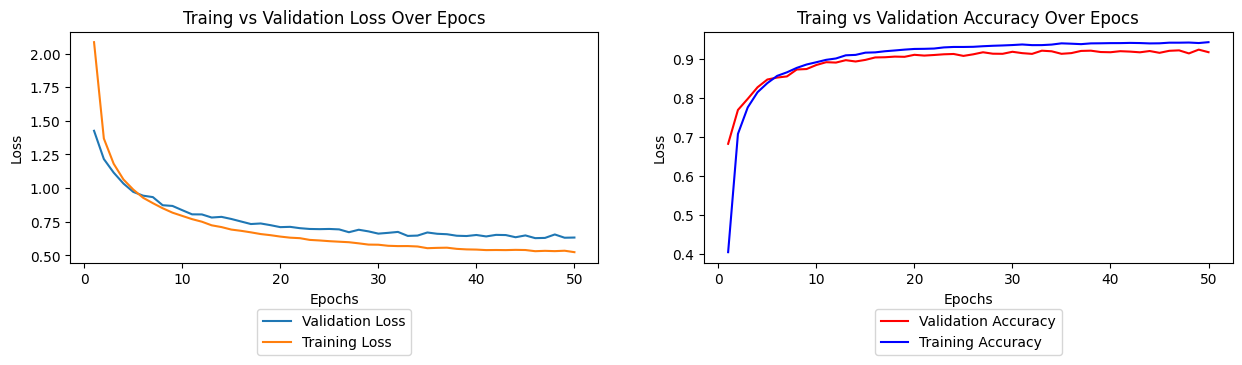

In [ ]:
# Collecting information from history_3
# Traing, 
t_accuracy_array = history_3.history['accuracy'] # Accuracy
tra_loss_array = history_3.history['loss'] # Loss

# Validation,
val_accuracy_array = history_3.history['val_accuracy'] # Accuracy
val_loss_array = history_3.history['val_loss'] # Loss

epochs_space = np.arange(1, len(val_loss_array)+1) # Number of epochs utilised

#  Setting up a subplot
fig, ax = plt.subplots(1,2,figsize=(15,3))

# Plotting the results
ax[0].plot(epochs_space, val_loss_array, label = 'Validation Loss')
ax[0].plot(epochs_space, tra_loss_array, label  = 'Training Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title('Traing vs Validation Loss Over Epocs')
ax[0].legend(loc = 'center', bbox_to_anchor=(0.5, -0.3))

ax[1].plot(epochs_space, val_accuracy_array, label = 'Validation Accuracy', color = 'red')
ax[1].plot(epochs_space, t_accuracy_array, label  = 'Training Accuracy', color = 'blue')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].set_title('Traing vs Validation Accuracy Over Epocs')
ax[1].legend(loc = 'center', bbox_to_anchor=(0.5, -0.3))


# Save the plot
#plt.savefig('plot_best_model.png', bbox_inches='tight')

Saving best model

In [ ]:
#model3.save('best_model.keras')

Loading best model

In [289]:
load_best_model = tf.keras.models.load_model('model_history_NN/best_model.keras')

I0000 00:00:1734548407.482793  260547 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


I0000 00:00:1734548558.027951  891009 service.cc:148] XLA service 0x7f82c00055e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1734548558.029088  891009 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Laptop GPU, Compute Capability 8.6
2024-12-18 19:02:38.109789: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1734548558.220955  891009 cuda_dnn.cc:529] Loaded cuDNN version 90300


 44/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9058 - loss: 0.6598

I0000 00:00:1734548561.693693  891009 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9213 - loss: 0.6238


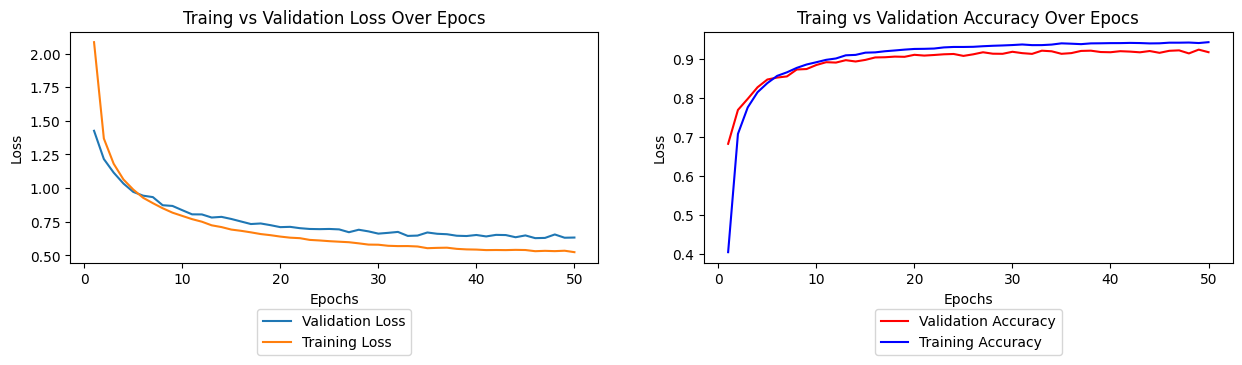

In [299]:
from IPython.display import Image

loss, accuracy = load_best_model.evaluate(x_test_, y_test_flatten)
Image('model_history_NN/plot_best_model.png')

3. Now, showcase the performance using other inference algorithms implemented in `scikit-learn` covered in the lectures such as random forest classifiers and support vector machines and compare the performance. Note that you are not required to describe the algorithms in detail. 

#### Random Forest

In [12]:
''' 
RandomForestClassifier takes a feature matrix, say X, as a 2D array of shape (n_samples, n_features).
From the previus question x_train_new and x_test_new are 3D arrays, hence, before proceding with RandomForsestClassifier,
one needs to reshape x_train_new and x_test_new.
'''
# reshapeing x_train_new and x_test_new into 2D arrays
# for this task one can use .reshape

x_train_flattened = x_train_new.reshape(x_train_new.shape[0], -1)
x_test_flattened = x_test_new.reshape(x_test_new.shape[0], -1)

print('Checking if reshaping as been computed correctly:')
print('x_train_flattened shape', x_train_flattened.shape)
print('x_test_flattened shape', x_test_flattened.shape)


Checking if reshaping as been computed correctly:
x_train_flattened shape (64000, 1568)
x_test_flattened shape (16000, 1568)


#### Hyper-Parameter Tuning
To determine which parameters and their values are best for Random Forest, one can perform hyperparameter tuning using `optuna`

In [ ]:
# Importing required packages and libraries
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

# Assigning a shorter label to train and test sets
X_train = x_train_flattened
X_test = x_test_flattened

# Define the objective function for Optuna
def objective(trial):
    # Suggest values for hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 10, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    
    # Create the model with the suggested hyperparameters
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=1,
        n_jobs=-1
    )
    
    # Evaluate using cross-validation
    scores = cross_val_score(rf, X_train, y_train_new, cv=3, scoring='accuracy')
    return scores.mean()  # Return mean accuracy

# Create a study and optimize
study = optuna.create_study(direction='maximize')  # We want to maximize accuracy
study.optimize(objective, n_trials=50)

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

# Train a final model with the best hyperparameters
best_rf = RandomForestClassifier(
    n_estimators=study.best_params['n_estimators'],
    max_depth=study.best_params['max_depth'],
    min_samples_split=study.best_params['min_samples_split'],
    min_samples_leaf=study.best_params['min_samples_leaf'],
    max_features=study.best_params['max_features'],
    random_state=1,
    n_jobs=-1
)
best_rf.fit(X_train, y_train_new)

# Test the final model
y_pred = best_rf.predict(X_test)
accuracy = accuracy_score(y_test_new, y_pred)
print("Test accuracy:", accuracy)


[I 2024-12-06 11:01:59,355] A new study created in memory with name: no-name-c7062a14-23dd-423c-b952-28b6d8870f54
[I 2024-12-06 11:02:27,251] Trial 0 finished with value: 0.7218905318480817 and parameters: {'n_estimators': 132, 'max_depth': 37, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7218905318480817.
[I 2024-12-06 11:02:49,637] Trial 1 finished with value: 0.723406094838072 and parameters: {'n_estimators': 109, 'max_depth': 25, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.723406094838072.
[I 2024-12-06 11:03:18,523] Trial 2 finished with value: 0.7189217200800191 and parameters: {'n_estimators': 149, 'max_depth': 48, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.723406094838072.
[I 2024-12-06 11:13:47,596] Trial 3 finished with value: 0.6515623794704196 and parameters: {'n_estimators': 138, 'max_depth': 30, 'min_

Best hyperparameters: {'n_estimators': 194, 'max_depth': 23, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Test accuracy: 0.7791875


Now let us save the best results obtained and the hyperparameters values utilised.

In [ ]:
import joblib

# Save the trained model as a pickle file
# joblib.dump(best_rf, 'best_random_forest_model.pkl')
print("Model saved as best_random_forest_model.pkl")

Model saved as best_random_forest_model.pkl


In [ ]:
load_best_rf = joblib.load('best_random_forest_model.pkl')

Best score obtained with Random Forest: 0.7791875


In [10]:
print('Visualising train and test score acieved from best model:')
print('')
print('Score train:',load_best_rf.score(x_train_flattened, y_train_new))
print('Score test:', load_best_rf.score(x_test_flattened, y_test_new))

Visualising train and test score acieved from best model:

Score train: 0.999859375
Score test: 0.7791875


Test accuracy: 0.7791875

The following sets of images is a sample from the test set, that as not been correctly predicted,
here we are comparing the predicted value and the to the actual value.


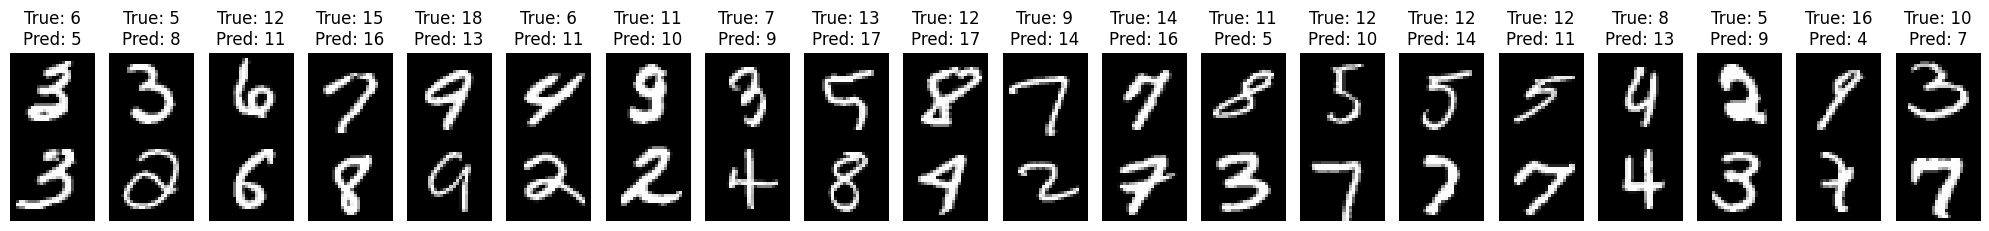

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

predicted = load_best_rf.predict(x_test_flattened)

accuracy = accuracy_score(y_test_new, predicted)
print('Test accuracy:', accuracy)
print('')
print('''The following sets of images is a sample from the test set, that as not been correctly predicted,
here we are comparing the predicted value and the to the actual value.''')

# Identify misclassified indices
misclassified_indices = np.where(predicted != y_test_new)[0]

# Display some misclassified examples
num_images_to_display = 20 # Number of images to show
plt.figure(figsize=(20, 10))

for i, idx in enumerate(misclassified_indices[:num_images_to_display]):
    # Reshape the flattened image back to 2D (if needed)
    image = x_test_flattened[idx].reshape(56, 28)  # Adjust dimensions if not 28x28

    # Create a subplot
    plt.subplot(1, num_images_to_display, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {y_test_new[idx]}\nPred: {predicted[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


#### Support Vector Machine (SVM)

For SVM to work one needs to scale the input features this can be done with `sklearn.preprocessing`.

Scaling input:

In [13]:
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_flattened)
x_test_scaled = scaler.fit_transform(x_test_flattened)


In [14]:
print('Checking shape dataset is unchanged.')
print('')
print('Shape scaled x_train:', x_train_scaled.shape)
print('Shape scaled x_test:', x_test_scaled.shape)

Checking shape dataset is unchanged.

Shape scaled x_train: (64000, 1568)
Shape scaled x_test: (16000, 1568)


Since the SVM model requires a high computational power, it is prefered to perform hyper-parameter tuning with a smaller dataset, i.e. a subset of the orginal dataset selceted at random. Once hyper-parameter tuning has been completed, use the tuned hyper-parameter in the whole dataset.

In [15]:
from sklearn.model_selection import train_test_split

# Use a smaller subset for optimization
X_train_subset, _, y_train_subset, _ = train_test_split(x_train_flattened, y_train_new, test_size=0.8, random_state=1)
_, X_test_subset, _, y_test_subset = train_test_split(x_test_flattened, y_test_new, test_size=0.2, random_state=1)

In [29]:
print('Checking subsets shape.')
print('')
print('X_train_subset shape:', X_train_subset.shape)
print('X_test_subset shape:', X_test_subset.shape)
print('y_train_subset shape:', y_train_subset.shape)
print('y_test_subset shape:', y_test_subset.shape)

Checking subsets shape.

X_train_subset shape: (12800, 1568)
X_test_subset shape: (3200, 1568)
y_train_subset shape: (12800,)
y_test_subset shape: (3200,)


In [ ]:
# Importing required packages and libraries
import optuna
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

# Define the objective function for Optuna
def objective(trial):
    # Suggest values for hyperparameters
    C = trial.suggest_float('C', 0.1, 10, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])
    gamma = trial.suggest_float('gamma', 0.01, 1, log=True)
    degree = trial.suggest_int('degree', 2, 5)
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    max_iter = trial.suggest_int('max_iter', 100, 9600, step=500)
    
    # Create the model with the suggested hyperparameters
    svm_class = SVC(
        C=C,
        kernel=kernel,
        gamma=gamma if kernel in ['rbf', 'poly', 'sigmoid'] else 'scale',  # Gamma only relevant for these kernels
        degree=degree if kernel == 'poly' else 3,  # Degree relevant only for poly kernel
        class_weight=class_weight,
        max_iter=max_iter,
        random_state=1
    )
    
    # Evaluate using cross-validation
    scores = cross_val_score(svm_class, X_train_subset, y_train_subset, cv=3, scoring='accuracy', n_jobs=-1)
    return scores.mean()  # Return mean accuracy

# Create a study and optimize
study_svm = optuna.create_study(direction='maximize')  # We want to maximize accuracy
study_svm.optimize(objective, n_trials=10)

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

# Train a final model with the best hyperparameters
best_svm_class = SVC(
    C=study_svm.best_params['C'],
    kernel=study_svm.best_params['kernel'],
    gamma=study_svm.best_params['gamma'] if study.best_params['kernel'] in ['rbf', 'poly', 'sigmoid'] else 'scale',
    degree=study_svm.best_params['degree'] if study.best_params['kernel'] == 'poly' else 3,
    class_weight=study_svm.best_params['class_weight'],
    max_iter=study_svm.best_params['max_iter'],
    random_state=1
)
best_svm_class.fit(X_train_subset, y_train_subset)

# Test the final model
y_pred = best_svm_class.predict(X_test_subset)
accuracy = accuracy_score(y_test_subset, y_pred)
print("Test accuracy:", accuracy)

# 30m to run

[I 2024-12-06 20:16:46,984] A new study created in memory with name: no-name-4cf54b3e-186e-4129-bc46-bcbcaad1cc50
/root/Document/M1_Cw/mem97/ml_venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=2100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/root/Document/M1_Cw/mem97/ml_venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=2100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/root/Document/M1_Cw/mem97/ml_venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=2100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
[I 2024-12-06 20:19:02,624] Trial 0 finished with value: 0.2273437344634314 and parameters: {'C': 1.2861575925833348, 'kernel': 'linear', 'gamma': 0.1278424689872446,

Best hyperparameters: {'C': 1.7924643938759761, 'kernel': 'poly', 'gamma': 0.09096469362944756, 'degree': 5, 'class_weight': None, 'max_iter': 7100}


/root/Document/M1_Cw/mem97/ml_venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1600).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Test accuracy: 0.6425


In [ ]:
best_par=study.best_params

In [ ]:
svm_class = SVC(
    C=best_par['C'],
    kernel=best_par['kernel'],
    gamma=best_par['gamma'],
    degree=best_par['degree'],
    class_weight=best_par['class_weight'],
    max_iter=best_par['max_iter'],
    random_state=1
)
trained_svm_class=svm_class.fit(x_train_scaled, y_train_new)
#94m to run

/root/Document/M1_Cw/mem97/ml_venv/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=7100).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [ ]:
print('Visualising train and test score acieved from best model:')
print('')
print('Score train:',trained_svm_class.score(x_train_scaled, y_train_new))
print('Score test:', trained_svm_class.score(x_test_scaled, y_test_new))
# 40 min to run

Visualising train and test score acieved from best model:

Score train: 0.963828125
Score test: 0.6575


In [16]:
import joblib
# Saving best model for SVM
#joblib.dump(trained_svm_class, 'best_svm_model.pkl')

# loading best svm_model
best_svm_model = joblib.load('best_svm_model.pkl')

# If you want to replicate the above code run the following code
print('Visualising train and test score acieved from best model:')
print('')
print('Score train:',best_svm_model.score(x_train_scaled, y_train_new))
print('Score test:', best_svm_model.score(x_test_scaled, y_test_new))
# 40min to run

Visualising train and test score acieved from best model:

Score train: 0.963828125
Score test: 0.6575


4. Using a weak linear classifier, compare the classifier probabilities for a linear
classifier trained on the 56 ×28 dataset with the probabilities of a single linear classifier
which is applied on the two images sequentially. How do the performances on the test set
compare when trained with few samples (i.e. train with varying number of samples
including 50,100,500, and 1000 samples respectively).

#### Executing task 4

<b>Need to show two different settings.</b>

<b>Setting A:</b> A single linear classifier trained on the Combined Dataset
 - A weak linear classifier is trained on the 56x28 dataset
 - The dataset size 56x28=1568 features per sample.
 - Probabilities are directly output by this classifier for test samples 
 
<b>Setting B:</b> Sequential Application of single linear classifier
 - Rather than training a classifier on the combined MNIST (56x28), train separate classifiers on two parts sequentially (i.e. first 28x28, and then the second 28x28 dataset).
 - The output of the two classifiers are combined (i.e., averaged probabilities or via secondary classifier) to make the final decision

<b>Setting up the experiment</b>
To compare the two setting proposed, one can perform the following set of steps:

1. <u>Dataset Preparation</u>
  - To prepare the dataset with images reshaped into 56x28. 
  - Split the dataset into training and test sets.

2. <u>Verying Training Samples Sizes</u>
  - Training the classes on subsets of the training data with sizes $N = 50, 100, 500$ and $1000$ samples.
  - For each subset size:
     - Need to train the classifier(s) under Settings A and B.
     - Record probabilities and test performance.

3. <u>Evaluate Probabilities</u>
 - For Setting A, the classifier outputs probabilities for each test sample directly. 
 - For Setting B:
     - Compute probabilities for each image part
     - Combine probabilities to generate final predictions.

4. <u>Test Performance Comparison</u>
 - Evaluate test performance using metrics like:
   - Accuracy
  

In [77]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.datasets import mnist # importing 28x28 dataset

(x_train, y_train), (x_test, y_test) = mnist.load_data() # Splitting data into traing and test sets


In [265]:
import numpy as np

np.random.seed(2) # fixed dataset
# Initialising parameters
# try 

N_train = 60000# training dataset size
N_test = 10000 # test dataset size

lenght_train = len(x_train)
lenght_test = len(x_test)

# Generating pairs of images for training and test dataset
x_train_pair = np.random.choice(np.arange(lenght_train), size = (N_train, 2))
x_test_pair = np.random.choice(np.arange(lenght_test), size = (N_test, 2))

# Summing the values of each images from training and test datasets
y_train_new = y_train[x_train_pair[:,0]] + y_train[x_train_pair[:,1]]
y_test_new = y_test[x_test_pair[:,0]] + y_test[x_test_pair[:,1]]

# Generating 56x28 images
x_train_new = np.append(x_train[x_train_pair[:,0]], x_train[x_train_pair[:,1]], axis=1)
x_test_new = np.append(x_test[x_test_pair[:,0]], x_test[x_test_pair[:,1]], axis=1)

Model adopted: Linear SVM with Minimal Margins

Support Vector Machines (SVM) with a linear kernel can act as weak classifiers if the margin is too small or the dataset is not well-separated.
Poor performance can result from weak regularization or insufficient data.

Setup:

In [266]:
# Flattening for Setting A: Concatenated images (56x28)
x_train_flattened_A = x_train_new.reshape(x_train_new.shape[0], -1)
x_test_flattened_A = x_test_new.reshape(x_test_new.shape[0], -1)

# Flattening for Setting B: Original MNIST images (28x28)
x_train_flattened_B = x_train.reshape(x_train.shape[0], -1)
x_test_flattened_B = x_test.reshape(x_test.shape[0], -1)


In [267]:
from sklearn.preprocessing import StandardScaler

#s Setting up x train and test for setting A and B
scaler  = StandardScaler()

x_train_scaled_A = scaler.fit_transform(x_train_flattened_A)
x_test_scaled_A = scaler.fit_transform(x_test_flattened_A)


In [268]:
x_train_scaled_B = scaler.fit_transform(x_train_flattened_B)
x_test_scaled_B = scaler.fit_transform(x_test_flattened_B)

In [269]:
# cheching shapes
print(x_train_scaled_A.shape)
print(x_test_scaled_A.shape)
print(x_train_scaled_B.shape)
print(x_test_scaled_B.shape)

(60000, 1568)
(10000, 1568)
(60000, 784)
(10000, 784)


Setting A porbabilities

In [272]:
def setting_A(i):
    s_train = [1/1500, 1/750, 1/150, 1/75] # different size
    s_test = [1/1000, 1/500, 1/100, 1/50]

    x_train_small_A, _, y_train_small_A, _ = train_test_split(x_train_flattened_A, y_train_new, train_size=s_train[i], random_state=1)
    _, x_test_small_A, _, y_test_small_A = train_test_split(x_test_flattened_A, y_test_new, test_size=s_test[i], random_state=1)

    svm_class = SVC(C=0.01,   kernel='linear',  tol=1.0, max_iter=1000, random_state=1, probability=True)
    trained_svm_class = svm_class.fit(x_train_small_A, y_train_small_A)

    y_pred = trained_svm_class.predict(x_test_small_A)

    # Calculate accuracy
    accuracy = accuracy_score(y_test_small_A, y_pred) 

    # Get probabilities
    prob_A = trained_svm_class.predict_proba(x_test_small_A)

    return prob_A, y_test_small_A


Setting A accuracy

In [273]:
def setting_A_accuracy(i):
    s_train = [1/1500, 1/750, 1/150, 1/75] # different size
    s_test = [1/1000, 1/500, 1/100, 1/50]

    x_train_small_A, _, y_train_small_A, _ = train_test_split(x_train_flattened_A, y_train_new, train_size=s_train[i], random_state=1)
    _, x_test_small_A, _, y_test_small_A = train_test_split(x_test_flattened_A, y_test_new, test_size=s_test[i], random_state=1)

    svm_class = SVC(C=0.01,   kernel='linear',  tol=1.0, max_iter=1000, random_state=1)
    trained_svm_class = svm_class.fit(x_train_small_A, y_train_small_A)

    y_pred = trained_svm_class.predict(x_test_small_A)

    # Calculate accuracy
    accuracy = accuracy_score(y_test_small_A, y_pred) 

    return accuracy

Setting B probabilities

In [274]:
def setting_B(i):
    s_train = [1/1500, 1/750, 1/150, 1/75] # different size
    s_test = [1/1000, 1/500, 1/100, 1/50]

    
    x_train_small_B1, _, y_train_small_B1, _ = train_test_split(x_train_flattened_B, y_train, train_size=s_train[i], random_state=1)
    x_train_small_B2, _, y_train_small_B2, _ = train_test_split(x_train_flattened_B, y_train, train_size=s_train[i], random_state=2)

# Create test subsets
    _, x_test_small_B1, _, y_test_small_B1 = train_test_split(x_test_flattened_B, y_test, test_size=s_test[i], random_state=1)
    _, x_test_small_B2, _, y_test_small_B2 = train_test_split(x_test_flattened_B, y_test, test_size=s_test[i], random_state=2)

# Train SVM on the first image
    svm_class_1 = SVC(C=0.01, kernel="linear", tol=1.0, max_iter=1000, random_state=1, probability=True)
    trained_svm_class_1 = svm_class_1.fit(x_train_small_B1, y_train_small_B1)

# Train SVM on the second image
    svm_class_2 = SVC(C=0.01, kernel="linear", tol=1.0, max_iter=1000, random_state=2, probability=True)
    trained_svm_class_2 = svm_class_2.fit(x_train_small_B2, y_train_small_B2)

# Predict for the first and second images
    y_pred_B1 = trained_svm_class_1.predict(x_test_small_B1)
    y_pred_B2 = trained_svm_class_2.predict(x_test_small_B2)

# Combine the predictions (sum of predictions)
    y_pred_combined = y_pred_B1 + y_pred_B2

# Combine ground truth labels
    y_test_combined = y_test_small_B1 + y_test_small_B2

# Calculate combined accuracy
    accuracy_combined = accuracy_score(y_test_combined, y_pred_combined)

    prob_B1 = trained_svm_class_1.predict_proba(x_test_small_B1)
    prob_B2 = trained_svm_class_2.predict_proba(x_test_small_B2)

    # Combine probabilities (average)
    combined_prob_B = (prob_B1 + prob_B2) / 2
    
    return combined_prob_B, y_test_combined

Setting B Accuracy

In [275]:
def setting_B_accuracy(i):
    s_train = [1/1500, 1/750, 1/150, 1/75] # different size
    s_test = [1/1000, 1/500, 1/100, 1/50]

    
    x_train_small_B1, _, y_train_small_B1, _ = train_test_split(x_train_flattened_B, y_train, train_size=s_train[i], random_state=1)
    x_train_small_B2, _, y_train_small_B2, _ = train_test_split(x_train_flattened_B, y_train, train_size=s_train[i], random_state=2)

# Create test subsets
    _, x_test_small_B1, _, y_test_small_B1 = train_test_split(x_test_flattened_B, y_test, test_size=s_test[i], random_state=1)
    _, x_test_small_B2, _, y_test_small_B2 = train_test_split(x_test_flattened_B, y_test, test_size=s_test[i], random_state=2)

# Train SVM on the first image
    svm_class_1 = SVC(C=0.01, kernel="linear", tol=1.0, max_iter=1000, random_state=1)
    trained_svm_class_1 = svm_class_1.fit(x_train_small_B1, y_train_small_B1)

# Train SVM on the second image
    svm_class_2 = SVC(C=0.01, kernel="linear", tol=1.0, max_iter=1000, random_state=2)
    trained_svm_class_2 = svm_class_2.fit(x_train_small_B2, y_train_small_B2)

# Predict for the first and second images
    y_pred_B1 = trained_svm_class_1.predict(x_test_small_B1)
    y_pred_B2 = trained_svm_class_2.predict(x_test_small_B2)

# Combine the predictions (sum of predictions)
    y_pred_combined = y_pred_B1 + y_pred_B2

# Combine ground truth labels
    y_test_combined = y_test_small_B1 + y_test_small_B2

# Calculate combined accuracy
    accuracy_combined = accuracy_score(y_test_combined, y_pred_combined)
    
    return accuracy_combined

In [276]:
accuracy_A = []
accuracy_B = []
for i in range(0, 4):
    A = setting_A_accuracy(i)
    B = setting_B_accuracy(i)
    accuracy_A.append(A)
    accuracy_B.append(B)
    

Working out probability for each digit to occur, for both settings A and B

In [277]:
prob_A50, prob_A100, prob_A500, prob_A1000 = setting_A(0), setting_A(1), setting_A(2), setting_A(3) # probabilities in A

In [278]:
prob_B50, prob_B100, prob_B500, prob_B1000 = setting_B(0), setting_B(1), setting_B(2), setting_B(3) # probabilities in B

Visualising one of the probabilities arrays in setting A, prob_A50.

In [279]:
import pandas as pd
import numpy as np

# Extract probabilities and true labels from prob_A50
probabilities_A50, true_labels_A50 = prob_A50

# Create DataFrame from probabilities
A50 = pd.DataFrame(probabilities_A50, columns=[f"Prob_Class_{i}" for i in range(probabilities_A50.shape[1])])

# Add Predicted Class (argmax of probabilities)
A50["Predicted_Class"] = np.argmax(probabilities_A50, axis=1)

# Add True Labels
A50["True_Label"] = true_labels_A50


''' 
Now repeate the above procedure for all prob_A
'''
# Extract probabilities and true labels from prob_A50
probabilities_A100, true_labels_A100 = prob_A100

# Create DataFrame from probabilities
A100 = pd.DataFrame(probabilities_A100, columns=[f"Prob_Class_{i}" for i in range(probabilities_A100.shape[1])])

# Add Predicted Class (argmax of probabilities)
A100["Predicted_Class"] = np.argmax(probabilities_A100, axis=1)

# Add True Labels
A100["True_Label"] = true_labels_A100


# Extract probabilities and true labels from prob_A50
probabilities_A500, true_labels_A500 = prob_A500

# Create DataFrame from probabilities
A500 = pd.DataFrame(probabilities_A500, columns=[f"Prob_Class_{i}" for i in range(probabilities_A500.shape[1])])

# Add Predicted Class (argmax of probabilities)
A500["Predicted_Class"] = np.argmax(probabilities_A500, axis=1)

# Add True Labels
A500["True_Label"] = true_labels_A500


# Extract probabilities and true labels from prob_A50
probabilities_A1000, true_labels_A1000 = prob_A1000

# Create DataFrame from probabilities
A1000 = pd.DataFrame(probabilities_A1000, columns=[f"Prob_Class_{i}" for i in range(probabilities_A1000.shape[1])])

# Add Predicted Class (argmax of probabilities)
A1000["Predicted_Class"] = np.argmax(probabilities_A1000, axis=1)

# Add True Labels
A1000["True_Label"] = true_labels_A1000

# Display the DataFrame
A50


,Prob_Class_0,Prob_Class_1,Prob_Class_2,Prob_Class_3,Prob_Class_4,Prob_Class_5,Prob_Class_6,Prob_Class_7,Prob_Class_8,Prob_Class_9,Prob_Class_10,Prob_Class_11,Prob_Class_12,Prob_Class_13,Prob_Class_14,Prob_Class_15,Prob_Class_16,Prob_Class_17,Predicted_Class,True_Label
0,0.028078,0.018711,0.033070,0.078441,0.064437,0.148944,0.023898,0.072795,0.067616,0.059138,0.068537,0.071596,0.027027,0.081017,0.035543,0.022870,0.028760,0.069521,5,15
1,0.033543,0.018787,0.035825,0.049419,0.077257,0.099327,0.043575,0.062113,0.068736,0.049304,0.091125,0.067890,0.033073,0.091286,0.039875,0.044055,0.026190,0.068618,5,4
2,0.026362,0.033187,0.026561,0.059091,0.073677,0.126742,0.021415,0.069432,0.102758,0.050199,0.064915,0.094499,0.026548,0.077771,0.032625,0.030144,0.022431,0.061644,5,10
3,0.025983,0.023847,0.031552,0.072781,0.083061,0.168867,0.022337,0.062598,0.094701,0.042251,0.041523,0.059143,0.028026,0.090266,0.026648,0.027415,0.023350,0.075650,5,12
4,0.021699,0.025807,0.033058,0.071356,0.126699,0.137408,0.016626,0.064303,0.046561,0.052091,0.072362,0.073258,0.019194,0.069943,0.030806,0.019859,0.019513,0.099459,5,11
5,0.033858,0.022230,0.036110,0.054577,0.115201,0.127953,0.041549,0.072608,0.057133,0.054226,0.053711,0.077915,0.037698,0.066522,0.036294,0.023739,0.031725,0.056949,5,7
6,0.026855,0.025872,0.029517,0.076828,0.087618,0.098101,0.029461,0.065922,0.054651,0.090601,0.072296,0.085316,0.029534,0.086530,0.045605,0.019347,0.031145,0.044799,5,8
7,0.024944,0.026090,0.023137,0.075451,0.102422,0.177551,0.022259,0.072146,0.079678,0.031614,0.053662,0.081579,0.026753,0.063166,0.026930,0.021929,0.021338,0.069350,5,12
8,0.027056,0.029015,0.024677,0.072560,0.072971,0.110366,0.026452,0.060490,0.072671,0.060852,0.065293,0.092963,0.034184,0.087535,0.028541,0.047026,0.034395,0.052950,5,6
9,0.019437,0.027683,0.018761,0.049994,0.082606,0.152905,0.037631,0.079773,0.092201,0.047858,0.060437,0.112065,0.034988,0.047757,0.023210,0.034768,0.039598,0.038328,5,10


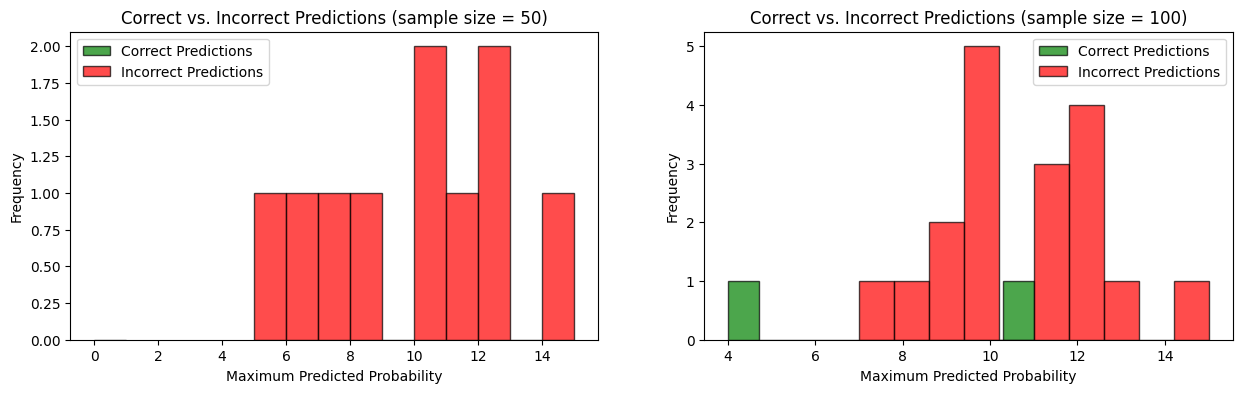

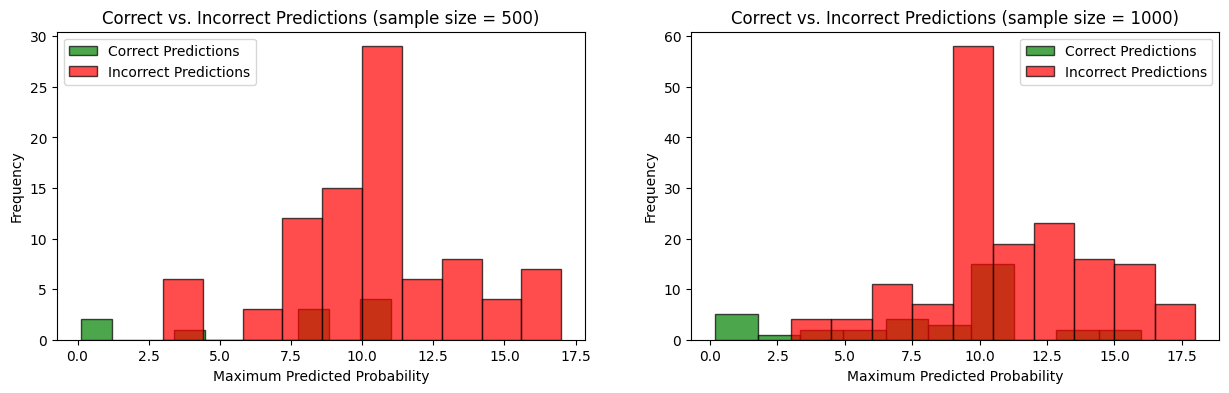

In [280]:
# Assinging correct or incorrect prediction for all data frames regarding setting A

# For A50
correct_preds_A50 = A50[A50["Predicted_Class"] == A50["True_Label"]]
incorrect_preds_A50 = A50[A50["Predicted_Class"] != A50["True_Label"]]
# For A100
correct_preds_A100 = A100[A100["Predicted_Class"] == A100["True_Label"]]
incorrect_preds_A100 = A100[A100["Predicted_Class"] != A100["True_Label"]]
# For A500
correct_preds_A500 = A500[A500["Predicted_Class"] == A500["True_Label"]]
incorrect_preds_A500 = A500[A500["Predicted_Class"] != A500["True_Label"]]
# For A1000
correct_preds_A1000 = A1000[A1000["Predicted_Class"] == A1000["True_Label"]]
incorrect_preds_A1000 = A1000[A1000["Predicted_Class"] != A1000["True_Label"]]

# Creating subplots 

fig1, ax1 = plt.subplots(1,2, figsize = (15,4))

ax1[0].hist(correct_preds_A50.max(axis=1), bins=10, alpha=0.7, label="Correct Predictions", color="green", edgecolor="black")
ax1[0].hist(incorrect_preds_A50.max(axis=1), bins=10, alpha=0.7, label="Incorrect Predictions", color="red", edgecolor="black")
ax1[0].set_xlabel("Maximum Predicted Probability")
ax1[0].set_ylabel("Frequency")
ax1[0].legend()
ax1[0].set_title("Correct vs. Incorrect Predictions (sample size = 50)")

ax1[1].hist(correct_preds_A100.max(axis=1), bins=10, alpha=0.7, label="Correct Predictions", color="green", edgecolor="black")
ax1[1].hist(incorrect_preds_A100.max(axis=1), bins=10, alpha=0.7, label="Incorrect Predictions", color="red", edgecolor="black")
ax1[1].set_xlabel("Maximum Predicted Probability")
ax1[1].set_ylabel("Frequency")
ax1[1].legend()
ax1[1].set_title("Correct vs. Incorrect Predictions (sample size = 100)")

fig2, ax2 = plt.subplots(1,2, figsize = (15,4))

ax2[0].hist(correct_preds_A500.max(axis=1), bins=10, alpha=0.7, label="Correct Predictions", color="green", edgecolor="black")
ax2[0].hist(incorrect_preds_A500.max(axis=1), bins=10, alpha=0.7, label="Incorrect Predictions", color="red", edgecolor="black")
ax2[0].set_xlabel("Maximum Predicted Probability")
ax2[0].set_ylabel("Frequency")
ax2[0].legend()
ax2[0].set_title("Correct vs. Incorrect Predictions (sample size = 500)")

ax2[1].hist(correct_preds_A1000.max(axis=1), bins=10, alpha=0.7, label="Correct Predictions", color="green", edgecolor="black")
ax2[1].hist(incorrect_preds_A1000.max(axis=1), bins=10, alpha=0.7, label="Incorrect Predictions", color="red", edgecolor="black")
ax2[1].set_xlabel("Maximum Predicted Probability")
ax2[1].set_ylabel("Frequency")
ax2[1].legend()
ax2[1].set_title("Correct vs. Incorrect Predictions (sample size = 1000)")


plt.show()


Visualising one of the probabilities arrays in setting B, prob_B50.

In [281]:
# Extract probabilities and true labels from prob_A50
probabilities, true_labels = prob_B50

# Create DataFrame from probabilities
B50 = pd.DataFrame(probabilities, columns=[f"Prob_Class_{i}" for i in range(probabilities.shape[1])])

# Add Predicted Class (argmax of probabilities)
B50["Predicted_Class"] = np.argmax(probabilities, axis=1)*2

# Add True Labels
B50["True_Label"] = true_labels

''' 
Now repeate the above procedure for all prob_B
'''
# Extract probabilities and true labels from prob_B50
probabilities_B100, true_labels_B100 = prob_B100

# Create DataFrame from probabilities
B100 = pd.DataFrame(probabilities_B100, columns=[f"Prob_Class_{i}" for i in range(probabilities_B100.shape[1])])

# Add Predicted Class (argmax of probabilities)
B100["Predicted_Class"] = np.argmax(probabilities_B100, axis=1)

# Add True Labels
B100["True_Label"] = true_labels_B100


# Extract probabilities and true labels from prob_B50
probabilities_B500, true_labels_B500 = prob_B500

# Create DataFrame from probabilities
B500 = pd.DataFrame(probabilities_B500, columns=[f"Prob_Class_{i}" for i in range(probabilities_B500.shape[1])])

# Add Predicted Class (argmax of probabilities)
B500["Predicted_Class"] = np.argmax(probabilities_B500, axis=1)

# Add True Labels
B500["True_Label"] = true_labels_B500


# Extract probabilities and true labels from prob_B50
probabilities_B1000, true_labels_B1000 = prob_B1000

# Create DataFrame from probabilities
B1000 = pd.DataFrame(probabilities_B1000, columns=[f"Prob_Class_{i}" for i in range(probabilities_B1000.shape[1])])

# Add Predicted Class (argmax of probabilities)
B1000["Predicted_Class"] = np.argmax(probabilities_B1000, axis=1)

# Add True Labels
B1000["True_Label"] = true_labels_A1000

# Display the DataFrame
B50


,Prob_Class_0,Prob_Class_1,Prob_Class_2,Prob_Class_3,Prob_Class_4,Prob_Class_5,Prob_Class_6,Prob_Class_7,Prob_Class_8,Prob_Class_9,Predicted_Class,True_Label
0,0.140970,0.028497,0.122674,0.082218,0.038529,0.097742,0.102181,0.076317,0.242031,0.068840,16,14
1,0.040739,0.031606,0.095053,0.118332,0.050022,0.101988,0.076955,0.168540,0.191772,0.124994,16,17
2,0.043041,0.067819,0.097074,0.099525,0.029995,0.090966,0.182561,0.208582,0.071025,0.109414,14,9
3,0.113277,0.055183,0.069688,0.086618,0.074407,0.121731,0.200003,0.082023,0.064937,0.132132,12,6
4,0.035716,0.025421,0.043874,0.061722,0.029344,0.102019,0.045367,0.349968,0.076691,0.229880,14,16
5,0.051320,0.022270,0.078083,0.077021,0.071720,0.144745,0.264093,0.050227,0.159092,0.081429,12,14
6,0.081880,0.226271,0.054616,0.109949,0.037030,0.133458,0.101504,0.066252,0.102634,0.086407,2,1
7,0.020879,0.056053,0.157218,0.062534,0.058200,0.076121,0.288084,0.052509,0.136141,0.092261,12,6
8,0.037933,0.094295,0.091720,0.107886,0.088539,0.157135,0.148192,0.068528,0.102450,0.103322,10,10
9,0.147424,0.210699,0.061119,0.133434,0.045761,0.082026,0.069916,0.081031,0.092481,0.076111,2,1


Note! For all probabilities in setting B the classes are limited between 0 and 9, as we are first training the model and then adding the digits together.

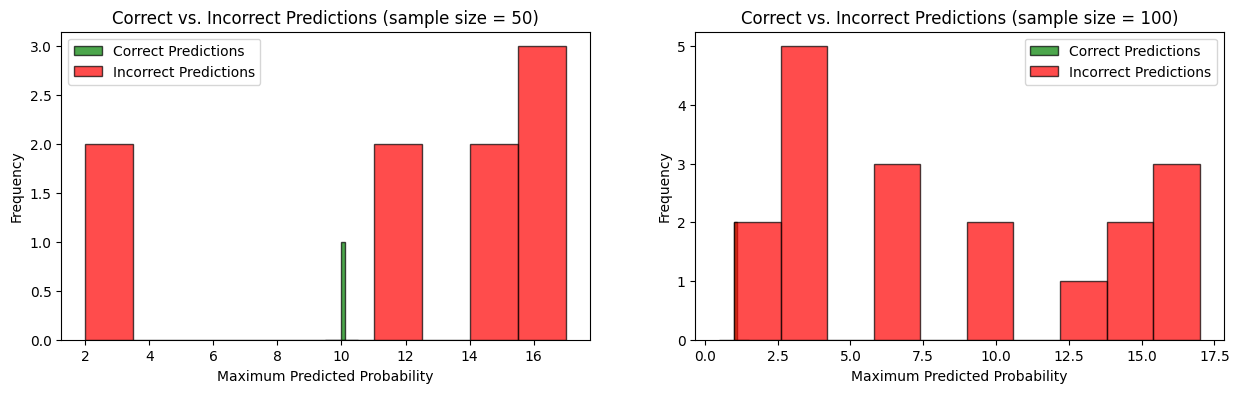

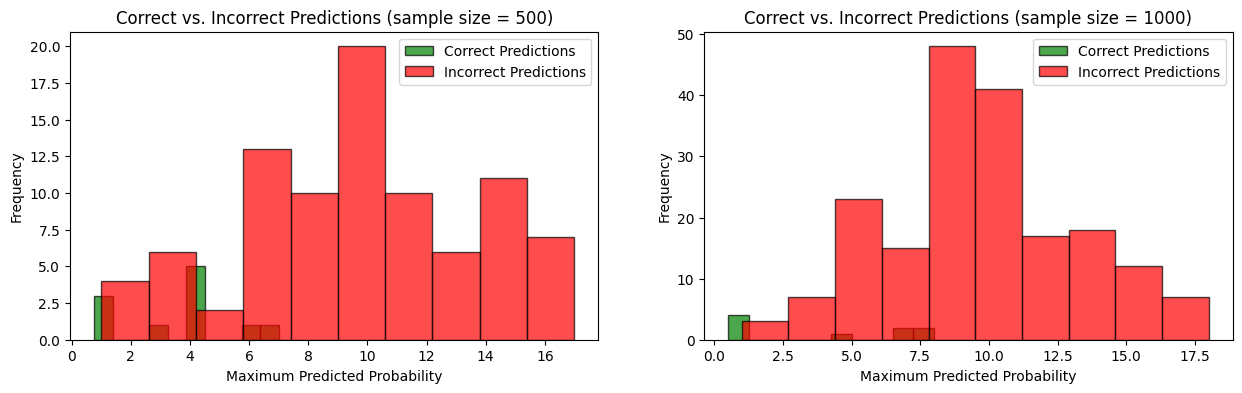

In [282]:
# Assinging correct or incorrect prediction for all data frames regarding setting B

# For B50
correct_preds_B50 = B50[B50["Predicted_Class"] == B50["True_Label"]]
incorrect_preds_B50 = B50[B50["Predicted_Class"] != B50["True_Label"]]
# For B100
correct_preds_B100 = B100[B100["Predicted_Class"] == B100["True_Label"]]
incorrect_preds_B100 = B100[B100["Predicted_Class"] != B100["True_Label"]]
# For B500
correct_preds_B500 = B500[B500["Predicted_Class"] == B500["True_Label"]]
incorrect_preds_B500 = B500[B500["Predicted_Class"] != B500["True_Label"]]
# For A1000
correct_preds_B1000 = B1000[B1000["Predicted_Class"] == B1000["True_Label"]]
incorrect_preds_B1000 = B1000[B1000["Predicted_Class"] != B1000["True_Label"]]

# Creating subplots 

fig1, ax1 = plt.subplots(1,2, figsize = (15,4))

ax1[0].hist(correct_preds_B50.max(axis=1), bins=10, alpha=0.7, label="Correct Predictions", color="green", edgecolor="black")
ax1[0].hist(incorrect_preds_B50.max(axis=1), bins=10, alpha=0.7, label="Incorrect Predictions", color="red", edgecolor="black")
ax1[0].set_xlabel("Maximum Predicted Probability")
ax1[0].set_ylabel("Frequency")
ax1[0].legend()
ax1[0].set_title("Correct vs. Incorrect Predictions (sample size = 50)")

ax1[1].hist(correct_preds_B100.max(axis=1), bins=10, alpha=0.7, label="Correct Predictions", color="green", edgecolor="black")
ax1[1].hist(incorrect_preds_B100.max(axis=1), bins=10, alpha=0.7, label="Incorrect Predictions", color="red", edgecolor="black")
ax1[1].set_xlabel("Maximum Predicted Probability")
ax1[1].set_ylabel("Frequency")
ax1[1].legend()
ax1[1].set_title("Correct vs. Incorrect Predictions (sample size = 100)")

fig2, ax2 = plt.subplots(1,2, figsize = (15,4))

ax2[0].hist(correct_preds_B500.max(axis=1), bins=10, alpha=0.7, label="Correct Predictions", color="green", edgecolor="black")
ax2[0].hist(incorrect_preds_B500.max(axis=1), bins=10, alpha=0.7, label="Incorrect Predictions", color="red", edgecolor="black")
ax2[0].set_xlabel("Maximum Predicted Probability")
ax2[0].set_ylabel("Frequency")
ax2[0].legend()
ax2[0].set_title("Correct vs. Incorrect Predictions (sample size = 500)")

ax2[1].hist(correct_preds_B1000.max(axis=1), bins=10, alpha=0.7, label="Correct Predictions", color="green", edgecolor="black")
ax2[1].hist(incorrect_preds_B1000.max(axis=1), bins=10, alpha=0.7, label="Incorrect Predictions", color="red", edgecolor="black")
ax2[1].set_xlabel("Maximum Predicted Probability")
ax2[1].set_ylabel("Frequency")
ax2[1].legend()
ax2[1].set_title("Correct vs. Incorrect Predictions (sample size = 1000)")


plt.show()

Comparing accuracies

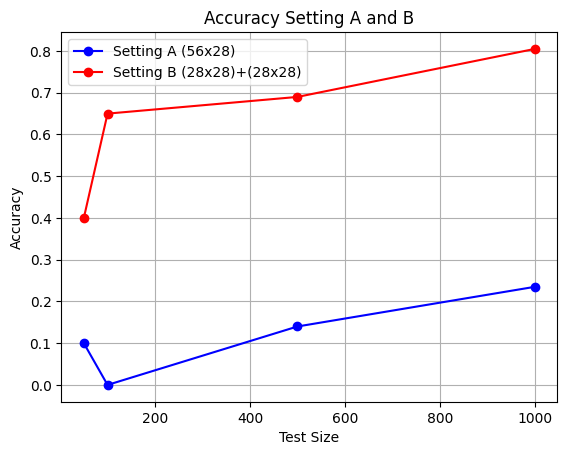

In [283]:
# Plotting accuracy results

test_size = [50 ,100, 500, 1000]

plt.plot(test_size, accuracy_A, color = 'blue', label = 'Setting A (56x28)', marker = 'o')
plt.plot(test_size, accuracy_B, color = 'red', label = 'Setting B (28x28)+(28x28)', marker = 'o')
plt.title('Accuracy Setting A and B')
plt.xlabel('Test Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

5. For your best performing neural network, show the t-SNE distribution of the
various classes in the embedding layer (i.e. the layer before the output). Compare this
representation with the representation obtained by directly applying t-SNE on the input
dataset. You should optimise the perplexity. 